# Exploring EW4 data

### IMERG
* temporal extent 2025-04-01 to 2025-09-30
* spatial exteent: latitude 0N to 20 N, longitude 27W to 20E


In [1]:
import pathlib
import datetime

In [2]:
import xarray

In [3]:
import matplotlib
import cartopy.crs

In [4]:
import site_archive_jasmin

ROOT_DIRECTORIES: {'ERA5lowres': '/gws/ssde/j25a/mmh_storage/theme3/weatherbench/5.625deg/', 'MOGLOBAL': '/gws/ssde/j25a/mmh_storage/theme3/mo_pet_site_archive/mo_global/', 'MOUKV': '/gws/ssde/j25a/mmh_storage/theme3/mo_pet_site_archive/mo_ukv/', 'Himawari': '/gws/ssde/j25a/mmh_storage/theme3/rv74_himawari', 'HimawariChannels': '/gws/ssde/j25a/mmh_storage/theme3/ra22_himawari', 'Rainfields3': '/gws/ssde/j25a/mmh_storage/theme3/rq0Radar', 'ew4_imerg_precip': '/gws/nopw/j04/ew4energy/imerg_2025_summer'}


In [5]:

import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe

In [6]:
from pyearthtools.data import Petdt
from pyearthtools.data.exceptions import DataNotFoundError
from pyearthtools.data.indexes import ArchiveIndex, decorators
from pyearthtools.data.transforms import Transform, TransformCollection
from pyearthtools.data.archive import register_archive


In [7]:
from site_archive_jasmin.utilities import (
    cached_exists,
    cached_iterdir,
)  # Could these be moved into a generic module?


In [8]:
# path_imerge_precip = pathlib.Path('/gws/nopw/j04/ew4energy/IMERG_PRECIP/3B-HHR-E.MS.MRG.3IMERG.20190101-S060000-E062959.0360.V07B.HDF5.nc4')
imerg_ew4_dir = pathlib.Path('/gws/nopw/j04/ew4energy/imerg_2025_summer')


In [9]:
xr_ds1 = xarray.open_dataset(imerg_ew4_dir / '3B-HHR-E.MS.MRG.3IMERG.20250930-S100000-E102959.0600.V07B.HDF5.SUB.nc4')

In [10]:
xr_ds1

<xarray.Dataset> Size: 382kB
Dimensions:        (time: 1, lon: 469, lat: 202)
Coordinates:
  * time           (time) datetime64[ns] 8B 2025-09-30T10:00:00
  * lon            (lon) float32 2kB -27.05 -26.95 -26.85 ... 19.55 19.65 19.75
  * lat            (lat) float32 808B 0.05 0.15 0.25 0.35 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, lon, lat) float32 379kB ...
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250930-S...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [11]:
xr_ds1['precipitation']


<xarray.DataArray 'precipitation' (time: 1, lon: 469, lat: 202)> Size: 379kB
[94738 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-09-30T10:00:00
  * lon      (lon) float32 2kB -27.05 -26.95 -26.85 -26.75 ... 19.55 19.65 19.75
  * lat      (lat) float32 808B 0.05 0.15 0.25 0.35 ... 19.85 19.95 20.05 20.15
Attributes:
    units:             mm/hr
    DimensionNames:    time,lon,lat
    Units:             mm/hr
    CodeMissingValue:  -9999.9
    LongName:          \nComplete merged microwave-infrared (gauge-adjusted)\...

In [12]:
float(min(xr_ds1['lat'])), float(max(xr_ds1['lat'])), float(min(xr_ds1['lon'])), float(max(xr_ds1['lon']))

(0.04999999701976776, 20.149999618530273, -27.049999237060547, 19.75)

(array([1862.,  736., 1058., 1315.,  949.,  948.,  614.,  133.,   73.,
          38.]),
 array([1.0e-03, 5.0e-02, 1.0e-01, 2.0e-01, 5.0e-01, 1.0e+00, 2.0e+00,
        4.0e+00, 8.0e+00, 1.6e+01, 3.2e+01]),
 <BarContainer object of 10 artists>)

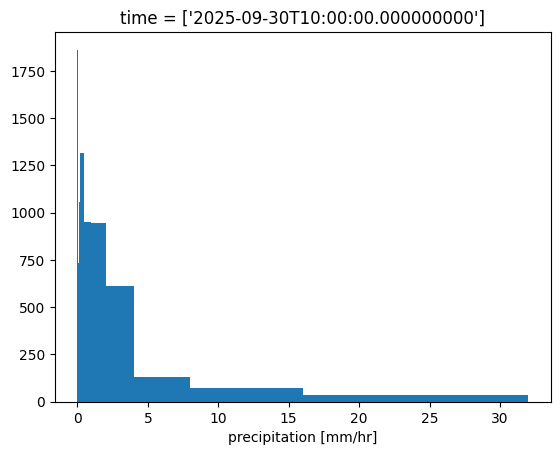

In [13]:
xr_ds1['precipitation'].plot.hist(bins=[1e-3,0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0])


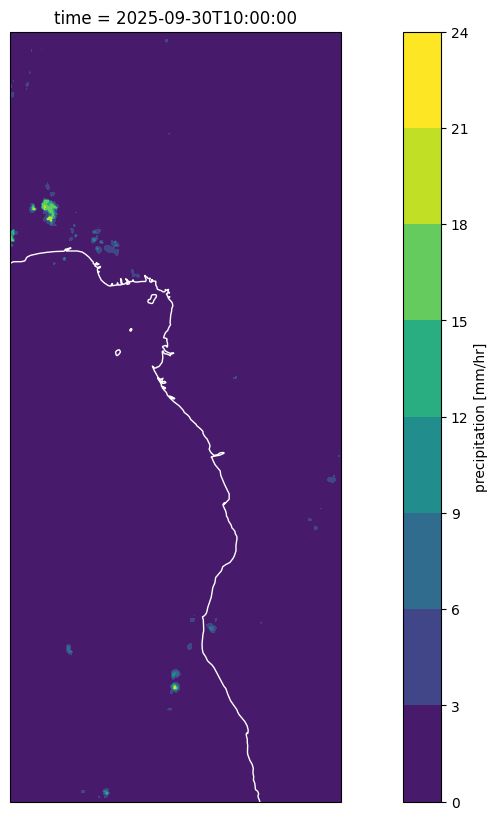

In [14]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
xr_ds1['precipitation'][0].plot.contourf(ax=ax1)
ax1.coastlines(color='w')

In [15]:
def get_imerg_path(start_dt, time_delta, fname_template, data_dir):
    day_minutes = start_dt.hour * 60 + start_dt.minute
    date_str = '{dt.year:04d}{dt.month:02d}{dt.day:02d}'.format(dt=start_dt)
    time_template = '{dt.hour:02d}{dt.minute:02d}{dt.second:02d}'
    start_time = time_template.format(dt=start_dt)
    end_time = time_template.format(dt=start_dt+time_delta-datetime.timedelta(seconds=1))
    imerg_path = data_dir / fname_template.format(date_str=date_str,
                                              start_time=start_time,
                                              end_time=end_time,
                                                  day_minutes=day_minutes,
                                             )
    return imerg_path


In [16]:
imerg_fname_template = '3B-HHR-E.MS.MRG.3IMERG.{date_str}-S{start_time}-E{end_time}.{day_minutes:04d}.V07B.HDF5.SUB.nc4'

In [17]:
get_imerg_path(
    datetime.datetime(2025,6,12,9,0),
    datetime.timedelta(minutes=30),
    imerg_fname_template,
    imerg_ew4_dir
)

PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250612-S090000-E092959.0540.V07B.HDF5.SUB.nc4')

In [18]:
xarray.open_dataset( get_imerg_path(
    datetime.datetime(2025,6,12,9,0),
    datetime.timedelta(minutes=30),
    imerg_fname_template,
    imerg_ew4_dir
))

<xarray.Dataset> Size: 382kB
Dimensions:        (time: 1, lon: 469, lat: 202)
Coordinates:
  * time           (time) datetime64[ns] 8B 2025-06-12T09:00:00
  * lon            (lon) float32 2kB -27.05 -26.95 -26.85 ... 19.55 19.65 19.75
  * lat            (lat) float32 808B 0.05 0.15 0.25 0.35 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, lon, lat) float32 379kB ...
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250612-S...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [19]:
start_dt = datetime.datetime(2025,5,1,0,0)
end_dt = datetime.datetime(2025,6,1,0,0)
time_delta=datetime.timedelta(minutes=30)

In [20]:
num_files = int((end_dt - start_dt) / time_delta)

In [21]:
imerg_filelist = [
    get_imerg_path(start_dt + (time_delta * time_ix),
                   time_delta,
                   imerg_fname_template,
                   imerg_ew4_dir
                  )
    for time_ix in range(num_files) ]


In [22]:
imerg_filelist[:5]

[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S000000-E002959.0000.V07B.HDF5.SUB.nc4'),
 PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S003000-E005959.0030.V07B.HDF5.SUB.nc4'),
 PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S010000-E012959.0060.V07B.HDF5.SUB.nc4'),
 PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S013000-E015959.0090.V07B.HDF5.SUB.nc4'),
 PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S020000-E022959.0120.V07B.HDF5.SUB.nc4')]

In [23]:
sum([f1.is_file() != True for f1 in imerg_filelist])

0

In [24]:
imerg_ds = xarray.open_mfdataset(imerg_filelist[:4])

In [25]:
imerg_ds

<xarray.Dataset> Size: 2MB
Dimensions:        (time: 4, lon: 469, lat: 202)
Coordinates:
  * time           (time) datetime64[ns] 32B 2025-05-01 ... 2025-05-01T01:30:00
  * lon            (lon) float32 2kB -27.05 -26.95 -26.85 ... 19.55 19.65 19.75
  * lat            (lat) float32 808B 0.05 0.15 0.25 0.35 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, lon, lat) float32 2MB dask.array<chunksize=(1, 469, 139), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250501-S...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [26]:
def date_matches(datetime1, datetime2):
    if datetime1.year != datetime2.year:
        return False
    if datetime1.month != datetime2.month:
        return False
    if datetime1.day != datetime2.day:
        return False
    return True


In [27]:
# @register_archive("ew4_imerg_2025", sample_kwargs=dict())
# class Ew4Imerg(ArchiveIndex):
#     """PyEarthTools accessor to access the version of GPM IMERG prepared for the EW4Energy project"""

#     imerg_fname_template = '3B-HHR-E.MS.MRG.3IMERG.{date_str}-S{start_time}-E{end_time}.{day_minutes:04d}.V07B.HDF5.SUB.nc4'
#     ew4_imerge_res = (30, "minute")
#     # ew4_imerge_res = (1, "hour")
#     @property
#     def _desc_(self):
#         return {
#             "singleline": "GPM IMERG - EW4Energy project ",
#             "range": "2025-04-01 to 2025-09-30",
#             "Documentation": "https://gpm.nasa.gov/data/imerg",
#         }

#     def __init__(
#         self,
#         start: datetime.datetime | str,
#         end: datetime.datetime | str,
        
#         *,
#         transforms: Transform | TransformCollection | None = None,
#     ):
#         """
#         Doc string for init function
#         """

#         print(start)
#         print(end)
#         if type(start) is not datetime.datetime:
#             self._start = datetime.datetime.fromisoformat(start)
#         else:
#             self._start = datetime.datetime(start)

#         if type(end) is not datetime.datetime:
#             self._end = datetime.datetime.fromisoformat(end)
#         else:
#             self._end = datetime.datetime(end)
#         self._time_delta=datetime.timedelta(minutes=30)        
        
        
#         # call the base class
#         super().__init__(
#             transforms=transforms,
#             data_interval=Ew4Imerg.ew4_imerge_res,
#         )
#         self.record_initialisation()

#     def filesystem(
#         self,
#         querytime: str | Petdt,
#     ) -> pathlib.Path | dict[str, str ]:
        
#         paths = {}
#         querytime = Petdt(querytime)
#         print(querytime)

#         ew4_imerg_dir = pathlib.Path(self.ROOT_DIRECTORIES['ew4_imerg_precip'])
        
#         num_files = int((end_dt - start_dt) / time_delta)
#         timestamp_list = [start_dt + (time_delta * time_ix) for time_ix in range(num_files) 
#                           if date_matches(start_dt + (time_delta * time_ix), querytime)
#                          ]
#         imerg_filelist = [ get_imerg_path(select_dt,
#                                           time_delta,
#                                           Ew4Imerg.imerg_fname_template,
#                                           ew4_imerg_dir
#                                          )
#                            for select_dt in timestamp_list ]
        
#         paths['precipitation'] = imerg_filelist
        
#         return paths

In [28]:
ew4_imerg_accessor = site_archive_jasmin.Ew4Imerg('2025-04-01 00:00', '2025-07-01 00:00')

2025-04-01 00:00
2025-07-01 00:00


In [29]:
ew4_imerg_accessor

Ew4Imerg
	Description                    GPM IMERG - EW4Energy project 
		 range                          '2025-04-01 to 2025-09-30'
		 Documentation                  'https://gpm.nasa.gov/data/imerg'


	Initialisation                 
		 end                            '2025-07-01 00:00'
		 start                          '2025-04-01 00:00'
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

In [30]:
ew4_imerg_accessor['2025-05-23']

2025-05-23T00:00
2025-05-23T00:00
2025-05-23T00:30
2025-05-23T00:30
2025-05-23T01:00
2025-05-23T01:00
2025-05-23T01:30
2025-05-23T01:30
2025-05-23T02:00
2025-05-23T02:00
2025-05-23T02:30
2025-05-23T02:30
2025-05-23T03:00
2025-05-23T03:00
2025-05-23T03:30
2025-05-23T03:30
2025-05-23T04:00
2025-05-23T04:00
2025-05-23T04:30
2025-05-23T04:30
2025-05-23T05:00
2025-05-23T05:00
2025-05-23T05:30
2025-05-23T05:30
2025-05-23T06:00
2025-05-23T06:00
2025-05-23T06:30
2025-05-23T06:30
2025-05-23T07:00
2025-05-23T07:00
2025-05-23T07:30
2025-05-23T07:30
2025-05-23T08:00
2025-05-23T08:00
2025-05-23T08:30
2025-05-23T08:30
2025-05-23T09:00
2025-05-23T09:00
2025-05-23T09:30
2025-05-23T09:30
2025-05-23T10:00
2025-05-23T10:00
2025-05-23T10:30
2025-05-23T10:30
2025-05-23T11:00
2025-05-23T11:00
2025-05-23T11:30
2025-05-23T11:30
2025-05-23T12:00
2025-05-23T12:00
2025-05-23T12:30
2025-05-23T12:30
2025-05-23T13:00
2025-05-23T13:00
2025-05-23T13:30
2025-05-23T13:30
2025-05-23T14:00
2025-05-23T14:00
2025-05-23T14:

<xarray.Dataset> Size: 18MB
Dimensions:        (time: 48, longitude: 469, latitude: 202)
Coordinates:
  * time           (time) datetime64[ns] 384B 2025-05-23 ... 2025-05-23T23:30:00
  * longitude      (longitude) float32 2kB -27.05 -26.95 -26.85 ... 19.65 19.75
  * latitude       (latitude) float32 808B 0.05 0.15 0.25 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, longitude, latitude) float32 18MB dask.array<chunksize=(1, 469, 202), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    CDO:                                    Climate Data Operators version 1....

In [31]:
ghana_extents = {
    'latitude': (4.5,11.25),
    'longitude': (-3.5, 1.5),
}
ghana_pet_box = (ghana_extents['latitude'][0],
                 ghana_extents['longitude'][0],
                 ghana_extents['latitude'][1],
                 ghana_extents['longitude'][1],
                )

In [32]:
ew4_imerg_pipeline = petpipe.Pipeline(
    ew4_imerg_accessor,
    petpipe.modifications.TemporalRetrieval(
        concat=True,
        samples=((0,3,1))),
    petdata.transform.region.Bounding(*ghana_pet_box),  
    iterator=petpipe.iterators.DateRange('20250501T00', '20250511T00', interval='3 hours'), 
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)


In [33]:
ew4_imerg_pipeline['2025-05-05']

2025-05-05T00:00
2025-05-05T00:00
2025-05-05T00:30
2025-05-05T00:30
2025-05-05T01:00
2025-05-05T01:00
2025-05-05T01:30
2025-05-05T01:30
2025-05-05T02:00
2025-05-05T02:00
2025-05-05T02:30
2025-05-05T02:30
2025-05-05T03:00
2025-05-05T03:00
2025-05-05T03:30
2025-05-05T03:30
2025-05-05T04:00
2025-05-05T04:00
2025-05-05T04:30
2025-05-05T04:30
2025-05-05T05:00
2025-05-05T05:00
2025-05-05T05:30
2025-05-05T05:30
2025-05-05T06:00
2025-05-05T06:00
2025-05-05T06:30
2025-05-05T06:30
2025-05-05T07:00
2025-05-05T07:00
2025-05-05T07:30
2025-05-05T07:30
2025-05-05T08:00
2025-05-05T08:00
2025-05-05T08:30
2025-05-05T08:30
2025-05-05T09:00
2025-05-05T09:00
2025-05-05T09:30
2025-05-05T09:30
2025-05-05T10:00
2025-05-05T10:00
2025-05-05T10:30
2025-05-05T10:30
2025-05-05T11:00
2025-05-05T11:00
2025-05-05T11:30
2025-05-05T11:30
2025-05-05T12:00
2025-05-05T12:00
2025-05-05T12:30
2025-05-05T12:30
2025-05-05T13:00
2025-05-05T13:00
2025-05-05T13:30
2025-05-05T13:30
2025-05-05T14:00
2025-05-05T14:00
2025-05-05T14:

<xarray.Dataset> Size: 3MB
Dimensions:        (time: 144, longitude: 98, latitude: 45)
Coordinates:
  * time           (time) datetime64[ns] 1kB 2025-05-05 ... 2025-05-07T23:30:00
  * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
  * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
Data variables:
    precipitation  (time, longitude, latitude) float32 3MB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    CDO:                                    Climate Data Operators version 1....

In [34]:
ew4_imerg_iter = iter(ew4_imerg_pipeline)

In [35]:
next(ew4_imerg_iter), 

2025-05-01T00:00
2025-05-01T00:00
2025-05-01T00:30
2025-05-01T00:30
2025-05-01T01:00
2025-05-01T01:00
2025-05-01T01:30
2025-05-01T01:30
2025-05-01T02:00
2025-05-01T02:00
2025-05-01T02:30
2025-05-01T02:30


(<xarray.Dataset> Size: 106kB
 Dimensions:        (time: 6, longitude: 98, latitude: 45)
 Coordinates:
   * time           (time) datetime64[ns] 48B 2025-05-01 ... 2025-05-01T02:30:00
   * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
   * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
 Data variables:
     precipitation  (time, longitude, latitude) float32 106kB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
 Attributes:
     CDI:                                    Climate Data Interface version 1....
     Conventions:                            CF-1.6
     Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
     Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
     CDO:                                    Climate Data Operators version 1....,)

In [36]:
next(ew4_imerg_iter), 

2025-05-01T03:00
2025-05-01T03:00
2025-05-01T03:30
2025-05-01T03:30
2025-05-01T04:00
2025-05-01T04:00
2025-05-01T04:30
2025-05-01T04:30
2025-05-01T05:00
2025-05-01T05:00
2025-05-01T05:30
2025-05-01T05:30


(<xarray.Dataset> Size: 106kB
 Dimensions:        (time: 6, longitude: 98, latitude: 45)
 Coordinates:
   * time           (time) datetime64[ns] 48B 2025-05-01T03:00:00 ... 2025-05-...
   * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
   * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
 Data variables:
     precipitation  (time, longitude, latitude) float32 106kB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
 Attributes:
     CDI:                                    Climate Data Interface version 1....
     Conventions:                            CF-1.6
     Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
     Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
     CDO:                                    Climate Data Operators version 1....,)

In [37]:
next(ew4_imerg_iter), next(ew4_imerg_iter),

2025-05-01T06:00
2025-05-01T06:00
2025-05-01T06:30
2025-05-01T06:30
2025-05-01T07:00
2025-05-01T07:00
2025-05-01T07:30
2025-05-01T07:30
2025-05-01T08:00
2025-05-01T08:00
2025-05-01T08:30
2025-05-01T08:30
2025-05-01T09:00
2025-05-01T09:00
2025-05-01T09:30
2025-05-01T09:30
2025-05-01T10:00
2025-05-01T10:00
2025-05-01T10:30
2025-05-01T10:30
2025-05-01T11:00
2025-05-01T11:00
2025-05-01T11:30
2025-05-01T11:30


(<xarray.Dataset> Size: 106kB
 Dimensions:        (time: 6, longitude: 98, latitude: 45)
 Coordinates:
   * time           (time) datetime64[ns] 48B 2025-05-01T06:00:00 ... 2025-05-...
   * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
   * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
 Data variables:
     precipitation  (time, longitude, latitude) float32 106kB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
 Attributes:
     CDI:                                    Climate Data Interface version 1....
     Conventions:                            CF-1.6
     Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
     Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
     CDO:                                    Climate Data Operators version 1....,
 <xarray.Dataset> Size: 106kB
 Dimensions:        (time: 6, longitude: 98, latitude: 45)
 Coordinates:
   * time           (time) d

In [ ]:
# load a sample file to find contents, especially variables

In [39]:
ew4_imerg_tw_pipe = petpipe.Pipeline(
    ew4_imerg_accessor,
    petpipe.modifications.TemporalWindow(prior_indexes=[-2,-1], posterior_indexes=[0], timedelta='30 minutes'),
    petdata.transform.region.Bounding(*ghana_pet_box),  
    iterator=petpipe.iterators.DateRange('20250501T00', '20250511T00', interval='3 hours'), 
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)


In [ ]:
#todo
# - find start and end time for data and select 1 day
# get all files
# load into dataset
# create a PET accessor to load those files
# demonstrate visualising
# create a demo autoencoder for the data
